In [1]:
# Install Streamlit
!pip install streamlit

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, IsolationForest

In [2]:
# Page Title
st.title("CAPSTONE_SHIP_GAS_TURBINE_FUEL_FLOW")

# Load Dataset
df = pd.read_csv("/content/data.csv")


2026-06-13 09:37:39.937 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:41.346 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-13 09:37:41.351 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:41.355 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [3]:
# Remove index column if present
if 'index' in df.columns:
    df.drop(columns=['index'], inplace=True)

In [4]:
# Remove extra spaces in column names
df.columns = df.columns.str.strip()


In [5]:
# Dataset Preview
st.subheader("Dataset Preview")
st.dataframe(df.head())

2026-06-13 09:37:48.039 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:48.041 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:48.042 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:48.084 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:48.084 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:48.085 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [6]:
# Dataset Information
st.subheader("Dataset Information")
st.write("Shape:", df.shape)


2026-06-13 09:37:50.379 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:50.381 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:50.382 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:50.383 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:50.386 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:50.387 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:50.389 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:50.391 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [7]:
# Missing Values
st.subheader("Missing Values")
st.write(df.isnull().sum())


2026-06-13 09:37:53.621 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:53.623 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:53.624 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:53.633 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:53.634 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:53.636 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-06-13 09:37:56.525 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:56.526 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:56.527 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:56.737 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:57.689 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:57.690 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:37:57.691 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

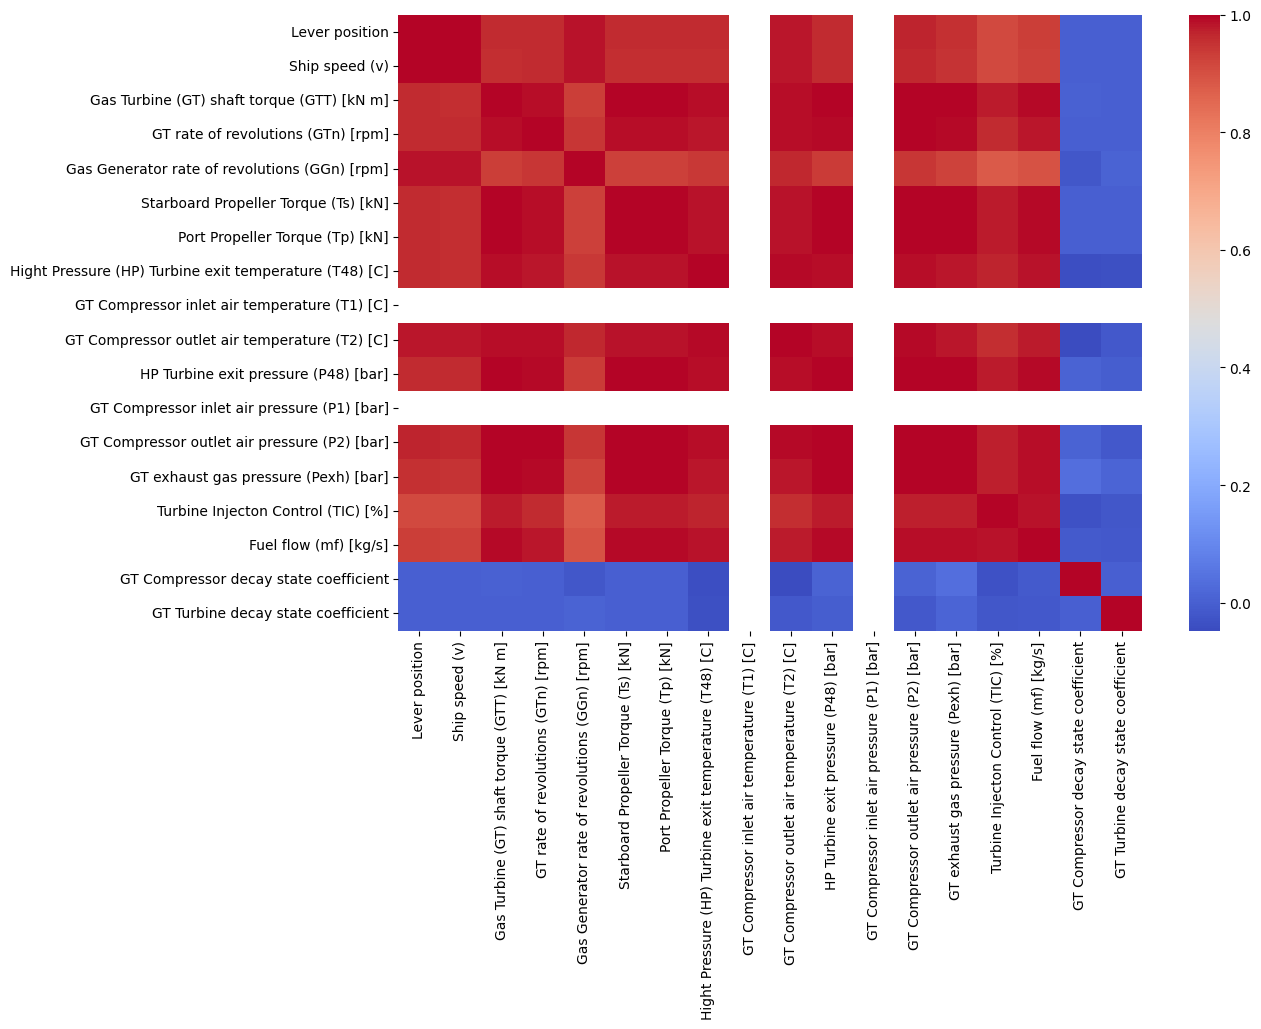

In [8]:
# Correlation Heatmap
st.subheader("Correlation Heatmap")

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df.corr(), cmap="coolwarm", ax=ax)
st.pyplot(fig)


In [9]:
# Fuel Flow Trend
st.subheader("Fuel Flow Trend")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df['Fuel flow (mf) [kg/s]'])
ax.set_title("Fuel Flow Trend")
ax.set_xlabel("Sample Index")
ax.set_ylabel("Fuel Flow")
st.pyplot(fig)

2026-06-13 09:38:03.642 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:03.645 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:03.645 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:03.662 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:04.522 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:04.523 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:04.524 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [10]:
# Speed vs Fuel Flow
st.subheader("Ship Speed vs Fuel Flow")

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(
    df['Ship speed (v)'],
    df['Fuel flow (mf) [kg/s]']
)
ax.set_xlabel("Ship Speed")
ax.set_ylabel("Fuel Flow")
ax.set_title("Ship Speed vs Fuel Flow")
st.pyplot(fig)


2026-06-13 09:38:06.411 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:06.414 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:06.415 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:06.431 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:06.653 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:06.654 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:06.656 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [11]:
# Fuel Flow Distribution
st.subheader("Fuel Flow Distribution")

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x=df['Fuel flow (mf) [kg/s]'], ax=ax)
st.pyplot(fig)

2026-06-13 09:38:09.445 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:09.446 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:09.447 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:09.526 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:09.606 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:09.606 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:09.609 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [12]:
# Machine Learning
st.subheader("Fuel Flow Prediction")

X = df.drop(columns=['Fuel flow (mf) [kg/s]'])
y = df['Fuel flow (mf) [kg/s]']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

accuracy = rf.score(X_test, y_test)

st.success(f"Model Accuracy (R² Score): {accuracy:.4f}")


2026-06-13 09:38:11.781 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:11.782 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:11.783 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:22.985 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:22.986 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:22.987 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [13]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [14]:
import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(model, file)


In [15]:
# Prediction Plot
y_pred = rf.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(y_test, y_pred)
ax.set_xlabel("Actual Fuel Flow")
ax.set_ylabel("Predicted Fuel Flow")
ax.set_title("Actual vs Predicted Fuel Flow")
st.pyplot(fig)

2026-06-13 09:38:58.851 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:59.043 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:59.043 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:38:59.044 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [16]:
# Anomaly Detection
st.subheader("Engine Health Monitoring (Anomaly Detection)")

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

df['Anomaly'] = iso.fit_predict(df)

fig, ax = plt.subplots(figsize=(8, 4))
scatter = ax.scatter(
    df.index,
    df['Fuel flow (mf) [kg/s]'],
    c=df['Anomaly'],
    cmap='coolwarm'
)

ax.set_title("Anomaly Detection in Fuel Flow")
ax.set_xlabel("Index")
ax.set_ylabel("Fuel Flow")

st.pyplot(fig)


2026-06-13 09:39:02.206 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:39:02.207 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:39:02.210 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:39:02.577 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:39:03.127 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:39:03.128 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:39:03.130 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [17]:
# Anomaly Summary
st.subheader("Anomaly Summary")
st.write(df['Anomaly'].value_counts())

2026-06-13 09:39:14.124 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:39:14.127 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:39:14.128 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:39:14.135 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:39:14.136 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 09:39:14.138 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [18]:
%%writefile app.py


Writing app.py


In [19]:
%%writefile requirements.txt
streamlit
pandas
matplotlib
seaborn
scikit-learn

Writing requirements.txt
